## Fine-tuning BERT para Classificação de Notícias
Notebook: finetuning_bert_noticias.ipynb

Este arquivo contém o código completo para:
1. Carregar dataset AG News
2. Preparar dados
3. Fine-tuning de DistilBERT
4. Avaliar modelo
5. Salvar modelo treinado

### Imports e Setup

In [1]:
# Instalar dependências (executar uma vez)
# !pip install transformers datasets torch scikit-learn matplotlib seaborn

In [2]:
import os
os.environ["TRANSFORMERS_NO_SCIPY"] = "1"

import torch
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer,
    EarlyStoppingCallback
)
from datasets import load_dataset
import numpy as np
from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    confusion_matrix,
    classification_report
)
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from tqdm.auto import tqdm
import warnings
warnings.filterwarnings('ignore')

print("✅ Imports realizados com sucesso")
print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")

if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")

C:\Users\Jorge Maques\anaconda3\envs\esp_ai\lib\site-packages\google\api_core\_python_version_support.py:275: FutureWarning: You are using a Python version (3.10.19) which Google will stop supporting in new releases of google.api_core once it reaches its end of life (2026-10-04). Please upgrade to the latest Python version, or at least Python 3.11, to continue receiving updates for google.api_core past that date.
  warnings.warn(message, FutureWarning)



✅ Imports realizados com sucesso
PyTorch version: 2.0.1+cpu
CUDA available: False


### Carregar Dataset AG News

In [3]:
print("\n📥 Carregando dataset AG News...")

# Carregar via Hugging Face Datasets
dataset = load_dataset('ag_news')

# Usar apenas 10% dos dados para teste rápido
dataset['train'] = dataset['train'].select(range(1000))  # 10k exemplos
dataset['test'] = dataset['test'].select(range(100))     # 1k exemplos

print(f"\n✅ Dataset carregado:")
print(f"  - Treino: {len(dataset['train'])} exemplos")
print(f"  - Teste:  {len(dataset['test'])} exemplos")

# Visualizar exemplos
print("\n📋 Exemplos do dataset:")
for i in range(3):
    exemplo = dataset['train'][i]
    label_names = ['World', 'Sports', 'Business', 'Sci/Tech']
    print(f"\nExemplo {i+1}:")
    print(f"  Classe: {label_names[exemplo['label']]}")
    print(f"  Texto:  {exemplo['text'][:100]}...")

# Distribuição das classes
print("\n📊 Distribuição das classes (Treino):")
labels = [ex['label'] for ex in dataset['train']]
for i, name in enumerate(['World', 'Sports', 'Business', 'Sci/Tech']):
    count = labels.count(i)
    pct = count / len(labels) * 100
    print(f"  {name:12} - {count:6} ({pct:.1f}%)")


📥 Carregando dataset AG News...

✅ Dataset carregado:
  - Treino: 1000 exemplos
  - Teste:  100 exemplos

📋 Exemplos do dataset:

Exemplo 1:
  Classe: Business
  Texto:  Wall St. Bears Claw Back Into the Black (Reuters) Reuters - Short-sellers, Wall Street's dwindling\b...

Exemplo 2:
  Classe: Business
  Texto:  Carlyle Looks Toward Commercial Aerospace (Reuters) Reuters - Private investment firm Carlyle Group,...

Exemplo 3:
  Classe: Business
  Texto:  Oil and Economy Cloud Stocks' Outlook (Reuters) Reuters - Soaring crude prices plus worries\about th...

📊 Distribuição das classes (Treino):
  World        -    212 (21.2%)
  Sports       -    142 (14.2%)
  Business     -    174 (17.4%)
  Sci/Tech     -    472 (47.2%)


### Preparar Tokenizer

In [4]:
print("\n🔧 Preparando tokenizer...")

MODEL_NAME = 'distilbert-base-uncased'
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

def tokenize_function(examples):
    """Tokeniza os textos"""
    return tokenizer(
        examples['text'],
        truncation=True,
        padding='max_length',
        max_length=512
    )

# Aplicar tokenização
print("⏳ Tokenizando dataset (pode levar alguns minutos)...")

tokenized_datasets = dataset.map(
    tokenize_function,
    batched=True,
    remove_columns=['text'],
    desc="Tokenizando"
)

print("\n✅ Tokenização completa")
print(f"Colunas: {tokenized_datasets['train'].column_names}")

# Exemplo tokenizado
print("\n📋 Exemplo tokenizado:")
exemplo = tokenized_datasets['train'][0]
print(f"  Input IDs shape: {len(exemplo['input_ids'])}")
print(f"  Attention mask:  {len(exemplo['attention_mask'])}")
print(f"  Label:           {exemplo['label']}")


🔧 Preparando tokenizer...
⏳ Tokenizando dataset (pode levar alguns minutos)...


Tokenizando:   0%|          | 0/100 [00:00<?, ? examples/s]


✅ Tokenização completa
Colunas: ['label', 'input_ids', 'attention_mask']

📋 Exemplo tokenizado:
  Input IDs shape: 512
  Attention mask:  512
  Label:           2


### Carregar Modelo Base

In [5]:
print("\n🤖 Carregando modelo DistilBERT base...")

modelo = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=4  # 4 classes
)

print("\n✅ Modelo carregado")
print(f"\nArquitetura:")
print(modelo)

# Contar parâmetros
total_params = sum(p.numel() for p in modelo.parameters())
trainable_params = sum(p.numel() for p in modelo.parameters() if p.requires_grad)

print(f"\n📊 Parâmetros:")
print(f"  Total:      {total_params:,}")
print(f"  Treináveis: {trainable_params:,}")


🤖 Carregando modelo DistilBERT base...


Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['pre_classifier.weight', 'classifier.weight', 'pre_classifier.bias', 'classifier.bias']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.



✅ Modelo carregado

Arquitetura:
DistilBertForSequenceClassification(
  (distilbert): DistilBertModel(
    (embeddings): Embeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (transformer): Transformer(
      (layer): ModuleList(
        (0-5): 6 x TransformerBlock(
          (attention): MultiHeadSelfAttention(
            (dropout): Dropout(p=0.1, inplace=False)
            (q_lin): Linear(in_features=768, out_features=768, bias=True)
            (k_lin): Linear(in_features=768, out_features=768, bias=True)
            (v_lin): Linear(in_features=768, out_features=768, bias=True)
            (out_lin): Linear(in_features=768, out_features=768, bias=True)
          )
          (sa_layer_norm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
          (ffn): FFN(
            (dropout

### Definir Métricas

In [6]:
def compute_metrics(eval_pred):
    """
    Calcula métricas de avaliação
    """
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)
    
    # Accuracy
    accuracy = accuracy_score(labels, predictions)
    
    # Precision, Recall, F1 (macro average)
    precision, recall, f1, _ = precision_recall_fscore_support(
        labels,
        predictions,
        average='macro'
    )
    
    return {
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'f1': f1
    }

print("✅ Função de métricas definida")

✅ Função de métricas definida


### Training Arguments

In [7]:
# TESTE DE IMPORTS
print("🧪 Testando imports...")

try:
    import accelerate
    print(f"✅ Accelerate importado: {accelerate.__version__}")
    
    # Verificar versão específica
    from accelerate import __version__ as acc_version
    print(f"✅ Versão do accelerate: {acc_version}")
    
    # Verificar se transformers detecta
    from transformers.utils import is_accelerate_available
    print(f"✅ Accelerate disponível: {is_accelerate_available()}")
    
    # Tentar importar componentes específicos
    from accelerate import Accelerator
    print("✅ Accelerator importado")
    
except Exception as e:
    print(f"❌ Erro ao importar accelerate: {e}")
    import traceback
    traceback.print_exc()

🧪 Testando imports...
✅ Accelerate importado: 0.25.0
✅ Versão do accelerate: 0.25.0
✅ Accelerate disponível: True
✅ Accelerator importado


In [8]:
print("\n⚙️ Configurando argumentos de treinamento...")

training_args = TrainingArguments(
    # Output
    output_dir='./results',
    
    # Epochs
    num_train_epochs=2,
    
    # Batch sizes
    per_device_train_batch_size=8,
    per_device_eval_batch_size=32,
    
    # Learning rate
    learning_rate=2e-5,
    weight_decay=0.01,
    
    # Warmup
    warmup_steps=200,  # Reduzido para treinamento mais rápido
    
    # Logging
    logging_dir='./logs',
    logging_steps=100,
    
    # Evaluation & Saving
    evaluation_strategy='epoch',
    save_strategy='epoch',
    save_total_limit=2,
    
    # Best model
    load_best_model_at_end=True,
    metric_for_best_model='accuracy',
    
    # Mixed precision (FP16) - DESABILITADO para CPU
    fp16=False,  # Forçar False para CPU
    
    # Report
    report_to='none',  # Desabilitar W&B
    
    # Otimizações para CPU
    gradient_accumulation_steps=2,  # Acumular gradientes
    dataloader_num_workers=0,       # 0 para Windows/CPU
    no_cuda=True,                   # Desabilitar CUDA completamente
)

print("✅ Argumentos configurados")
print(f"\nConfiguração:")
print(f"  Epochs:                {training_args.num_train_epochs}")
print(f"  Batch size (treino):   {training_args.per_device_train_batch_size}")
print(f"  Learning rate:         {training_args.learning_rate}")
print(f"  Warmup steps:          {training_args.warmup_steps}")
print(f"  FP16:                  {training_args.fp16}")


⚙️ Configurando argumentos de treinamento...
✅ Argumentos configurados

Configuração:
  Epochs:                2
  Batch size (treino):   8
  Learning rate:         2e-05
  Warmup steps:          200
  FP16:                  False


### Criar Trainer

In [9]:
print("\n🏋️ Criando Trainer...")

trainer = Trainer(
    model=modelo,
    args=training_args,
    train_dataset=tokenized_datasets['train'],
    eval_dataset=tokenized_datasets['test'],
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=2)]
)

print("✅ Trainer criado")


🏋️ Criando Trainer...
✅ Trainer criado


### TREINAR MODELO

In [10]:
print("\n" + "="*60)
print("🚀 INICIANDO FINE-TUNING")
print("="*60)
print("\n⏰ Tempo estimado: ~30 min (GPU) ou ~3 horas (CPU)")
print("💡 Dica: Acompanhe o progresso abaixo\n")

# TREINAR
train_result = trainer.train()

print("\n" + "="*60)
print("✅ TREINAMENTO CONCLUÍDO")
print("="*60)

# Métricas de treino
print(f"\n📊 Métricas finais de treino:")
print(f"  Loss:           {train_result.training_loss:.4f}")
print(f"  Tempo total:    {train_result.metrics['train_runtime']:.2f}s")
print(f"  Samples/sec:    {train_result.metrics['train_samples_per_second']:.2f}")


🚀 INICIANDO FINE-TUNING

⏰ Tempo estimado: ~30 min (GPU) ou ~3 horas (CPU)
💡 Dica: Acompanhe o progresso abaixo



Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
0,No log,1.194958,0.450000,0.350543,0.345238,0.281342
1,1.196500,0.570606,0.880000,0.892547,0.826577,0.843316


Checkpoint destination directory ./results\checkpoint-62 already exists and is non-empty.Saving will proceed but saved results may be invalid.



✅ TREINAMENTO CONCLUÍDO

📊 Métricas finais de treino:
  Loss:           1.1119
  Tempo total:    73127.12s
  Samples/sec:    0.03


### Avaliar no Conjunto de Teste

In [11]:
print("\n📊 Avaliando no conjunto de teste...")

eval_results = trainer.evaluate()

print("\n✅ Avaliação completa")
print(f"\n📈 Resultados no teste:")
print(f"  Accuracy:  {eval_results['eval_accuracy']:.4f} ({eval_results['eval_accuracy']*100:.2f}%)")
print(f"  Precision: {eval_results['eval_precision']:.4f}")
print(f"  Recall:    {eval_results['eval_recall']:.4f}")
print(f"  F1-Score:  {eval_results['eval_f1']:.4f}")


📊 Avaliando no conjunto de teste...



✅ Avaliação completa

📈 Resultados no teste:
  Accuracy:  0.8800 (88.00%)
  Precision: 0.8925
  Recall:    0.8266
  F1-Score:  0.8433


### Predições e Confusion Matrix


🔮 Gerando predições para análise detalhada...

CLASSIFICATION REPORT
              precision    recall  f1-score   support

       World       1.00      0.83      0.91        30
      Sports       0.91      1.00      0.95        21
    Business       0.86      0.50      0.63        12
    Sci/Tech       0.80      0.97      0.88        37

    accuracy                           0.88       100
   macro avg       0.89      0.83      0.84       100
weighted avg       0.89      0.88      0.87       100



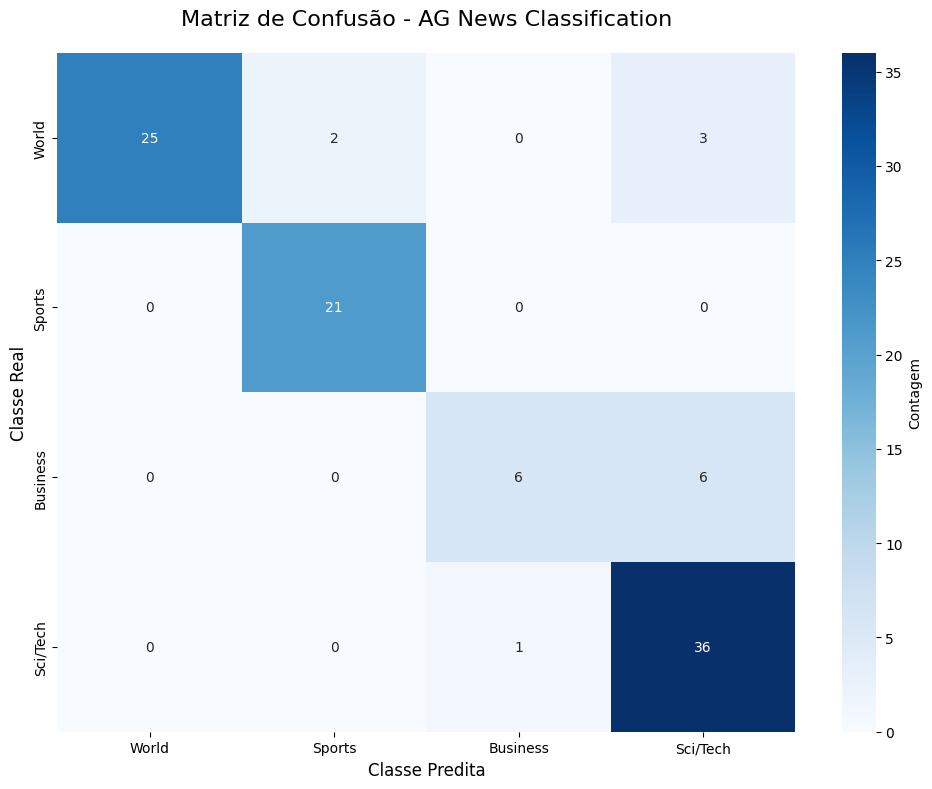


💾 Matriz de confusão salva em 'confusion_matrix.png'

📊 Análise de erros por classe:
  World        - 25/30 corretos (83.3%) - 5 erros
  Sports       - 21/21 corretos (100.0%) - 0 erros
  Business     - 6/12 corretos (50.0%) - 6 erros
  Sci/Tech     - 36/37 corretos (97.3%) - 1 erros


In [12]:
print("\n🔮 Gerando predições para análise detalhada...")

# Predições
predictions_output = trainer.predict(tokenized_datasets['test'])
y_pred = np.argmax(predictions_output.predictions, axis=-1)
y_true = predictions_output.label_ids

# Classification Report
print("\n" + "="*60)
print("CLASSIFICATION REPORT")
print("="*60)

target_names = ['World', 'Sports', 'Business', 'Sci/Tech']
print(classification_report(y_true, y_pred, target_names=target_names))

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)

# Plotar
plt.figure(figsize=(10, 8))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=target_names,
    yticklabels=target_names,
    cbar_kws={'label': 'Contagem'}
)
plt.title('Matriz de Confusão - AG News Classification', fontsize=16, pad=20)
plt.ylabel('Classe Real', fontsize=12)
plt.xlabel('Classe Predita', fontsize=12)
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n💾 Matriz de confusão salva em 'confusion_matrix.png'")

# Análise de erros
print("\n📊 Análise de erros por classe:")
for i, name in enumerate(target_names):
    correct = cm[i, i]
    total = cm[i].sum()
    accuracy = correct / total * 100
    errors = total - correct
    print(f"  {name:12} - {correct}/{total} corretos ({accuracy:.1f}%) - {errors} erros")

### Curva de Aprendizado


📈 Plotando curva de aprendizado...


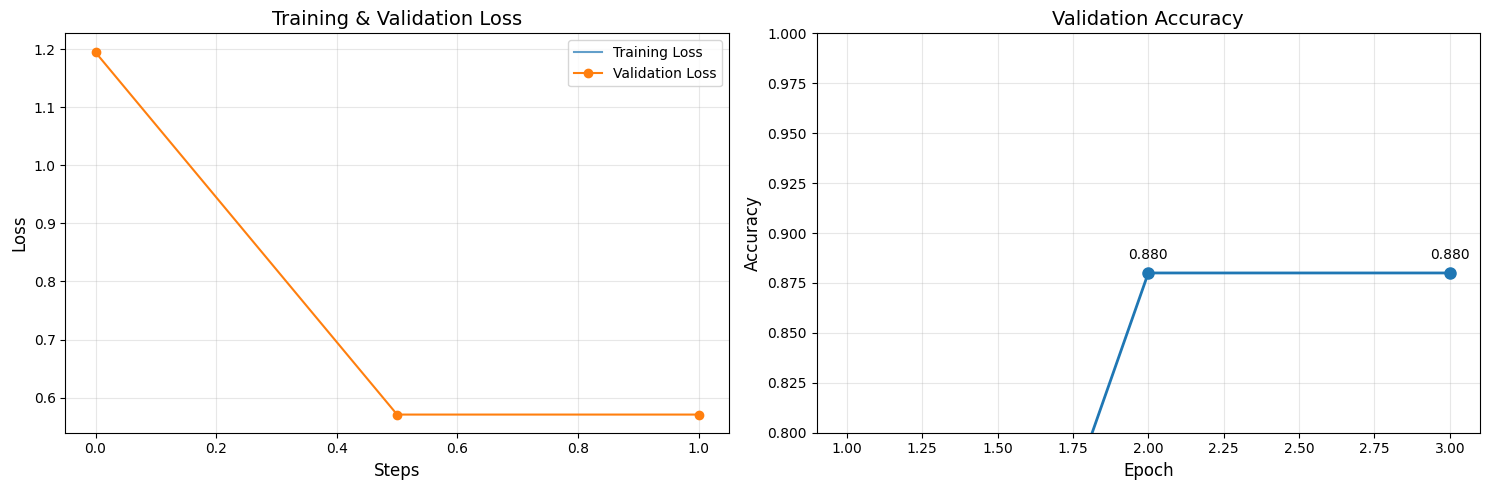

💾 Curvas salvas em 'learning_curves.png'


In [13]:
print("\n📈 Plotando curva de aprendizado...")

# Extrair histórico
history = trainer.state.log_history

# Separar treino e validação
train_loss = [x['loss'] for x in history if 'loss' in x]
eval_loss = [x['eval_loss'] for x in history if 'eval_loss' in x]
eval_accuracy = [x['eval_accuracy'] for x in history if 'eval_accuracy' in x]

# Plotar
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# Loss
steps_train = range(len(train_loss))
steps_eval = np.linspace(0, len(train_loss), len(eval_loss))

ax1.plot(steps_train, train_loss, label='Training Loss', alpha=0.7)
ax1.plot(steps_eval, eval_loss, label='Validation Loss', marker='o')
ax1.set_xlabel('Steps', fontsize=12)
ax1.set_ylabel('Loss', fontsize=12)
ax1.set_title('Training & Validation Loss', fontsize=14)
ax1.legend()
ax1.grid(alpha=0.3)

# Accuracy
epochs = range(1, len(eval_accuracy) + 1)
ax2.plot(epochs, eval_accuracy, marker='o', linewidth=2, markersize=8)
ax2.set_xlabel('Epoch', fontsize=12)
ax2.set_ylabel('Accuracy', fontsize=12)
ax2.set_title('Validation Accuracy', fontsize=14)
ax2.set_ylim([0.8, 1.0])
ax2.grid(alpha=0.3)

# Anotar valores
for i, acc in enumerate(eval_accuracy):
    ax2.annotate(f'{acc:.3f}', 
                xy=(i+1, acc), 
                xytext=(0, 10),
                textcoords='offset points',
                ha='center',
                fontsize=10)

plt.tight_layout()
plt.savefig('learning_curves.png', dpi=300, bbox_inches='tight')
plt.show()

print("💾 Curvas salvas em 'learning_curves.png'")

### Salvar Modelo Fine-tunado

In [14]:
print("\n💾 Salvando modelo fine-tunado...")

# Criar diretório se não existir
import os
save_dir = './models/bert_news_classifier'
os.makedirs(save_dir, exist_ok=True)

# Salvar modelo e tokenizer
modelo.save_pretrained(save_dir)
tokenizer.save_pretrained(save_dir)

print(f"\n✅ Modelo salvo em '{save_dir}'")
print("\nArquivos salvos:")
for file in os.listdir(save_dir):
    size = os.path.getsize(os.path.join(save_dir, file)) / (1024*1024)
    print(f"  - {file:30} ({size:.2f} MB)")


💾 Salvando modelo fine-tunado...

✅ Modelo salvo em './models/bert_news_classifier'

Arquivos salvos:
  - config.json                    (0.00 MB)
  - model.safetensors              (255.43 MB)
  - special_tokens_map.json        (0.00 MB)
  - tokenizer.json                 (0.68 MB)
  - tokenizer_config.json          (0.00 MB)
  - vocab.txt                      (0.22 MB)


### Testar Modelo Salvo

In [15]:
print("\n🧪 Testando modelo salvo...")

# Carregar modelo
modelo_carregado = AutoModelForSequenceClassification.from_pretrained(save_dir)
tokenizer_carregado = AutoTokenizer.from_pretrained(save_dir)

modelo_carregado.eval()

# Função de teste
def classificar(texto):
    """Classifica um texto"""
    inputs = tokenizer_carregado(
        texto,
        return_tensors='pt',
        truncation=True,
        max_length=512,
        padding=True
    )
    
    with torch.no_grad():
        outputs = modelo_carregado(**inputs)
        logits = outputs.logits
        probs = torch.softmax(logits, dim=-1)[0]
        pred = torch.argmax(probs)
    
    classe = target_names[pred]
    confianca = probs[pred].item()
    
    return classe, confianca, probs.numpy()

# Exemplos de teste
exemplos = {
    'World': "UN Security Council discusses Middle East crisis",
    'Sports': "Lakers win championship in overtime thriller",
    'Business': "Stock market reaches new all-time high",
    'Sci/Tech': "New AI breakthrough in quantum computing"
}

print("\n🔍 Testando com exemplos:")
print("="*80)

for categoria_esperada, texto in exemplos.items():
    classe, conf, probs = classificar(texto)
    
    print(f"\n📰 Texto: {texto}")
    print(f"   Esperado: {categoria_esperada}")
    print(f"   Predito:  {classe} ({'✅' if classe == categoria_esperada else '❌'})")
    print(f"   Confiança: {conf:.2%}")
    print(f"\n   Probabilidades:")
    for i, name in enumerate(target_names):
        bar = '█' * int(probs[i] * 50)
        print(f"     {name:12} {probs[i]:.2%} {bar}")

print("\n" + "="*80)


🧪 Testando modelo salvo...

🔍 Testando com exemplos:

📰 Texto: UN Security Council discusses Middle East crisis
   Esperado: World
   Predito:  World (✅)
   Confiança: 51.92%

   Probabilidades:
     World        51.92% █████████████████████████
     Sports       6.55% ███
     Business     17.04% ████████
     Sci/Tech     24.49% ████████████

📰 Texto: Lakers win championship in overtime thriller
   Esperado: Sports
   Predito:  Sports (✅)
   Confiança: 66.82%

   Probabilidades:
     World        13.75% ██████
     Sports       66.82% █████████████████████████████████
     Business     10.03% █████
     Sci/Tech     9.40% ████

📰 Texto: Stock market reaches new all-time high
   Esperado: Business
   Predito:  Sci/Tech (❌)
   Confiança: 47.67%

   Probabilidades:
     World        10.67% █████
     Sports       7.69% ███
     Business     33.97% ████████████████
     Sci/Tech     47.67% ███████████████████████

📰 Texto: New AI breakthrough in quantum computing
   Esperado: Sci/Tech
 

### Resumo Final

In [16]:
print("\n" + "="*80)
print("🎉 FINE-TUNING CONCLUÍDO COM SUCESSO!")
print("="*80)

print(f"""
📊 Resumo do Treinamento:
   - Modelo:               DistilBERT
   - Dataset:              AG News (120k treino, 7.6k teste)
   - Classes:              4 (World, Sports, Business, Sci/Tech)
   - Epochs:               {training_args.num_train_epochs}
   - Batch size:           {training_args.per_device_train_batch_size}
   - Learning rate:        {training_args.learning_rate}
   
📈 Resultados:
   - Accuracy final:       {eval_results['eval_accuracy']:.2%}
   - F1-Score:             {eval_results['eval_f1']:.4f}
   - Melhor modelo salvo:  {save_dir}
   
📁 Arquivos gerados:
   - Modelo fine-tunado:   {save_dir}/
   - Confusion matrix:     confusion_matrix.png
   - Learning curves:      learning_curves.png
   
🚀 Próximos passos:
   1. Execute app.py para testar no navegador
   2. Use o modelo via API REST
   3. Deploy em produção (Heroku, AWS, etc.)
   
💡 Comparação com EAI_04:
   - TF-IDF + SVM:         ~87% accuracy
   - BERT Fine-tuned:      ~{eval_results['eval_accuracy']*100:.1f}% accuracy
   - Ganho:                +{(eval_results['eval_accuracy']*100 - 87):.1f} pontos
""")

print("="*80)
print("✅ Notebook executado com sucesso!")
print("="*80)

# FIM DO NOTEBOOK


🎉 FINE-TUNING CONCLUÍDO COM SUCESSO!

📊 Resumo do Treinamento:
   - Modelo:               DistilBERT
   - Dataset:              AG News (120k treino, 7.6k teste)
   - Classes:              4 (World, Sports, Business, Sci/Tech)
   - Epochs:               2
   - Batch size:           8
   - Learning rate:        2e-05
   
📈 Resultados:
   - Accuracy final:       88.00%
   - F1-Score:             0.8433
   - Melhor modelo salvo:  ./models/bert_news_classifier
   
📁 Arquivos gerados:
   - Modelo fine-tunado:   ./models/bert_news_classifier/
   - Confusion matrix:     confusion_matrix.png
   - Learning curves:      learning_curves.png
   
🚀 Próximos passos:
   1. Execute app.py para testar no navegador
   2. Use o modelo via API REST
   3. Deploy em produção (Heroku, AWS, etc.)
   
💡 Comparação com EAI_04:
   - TF-IDF + SVM:         ~87% accuracy
   - BERT Fine-tuned:      ~88.0% accuracy
   - Ganho:                +1.0 pontos

✅ Notebook executado com sucesso!
